<a href="https://colab.research.google.com/github/Julss1195/Julss1195/blob/main/Customer_Clustering_and_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML WORK/customer_data.csv')

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data.shape[1]
data.head()

,Age,Annual Income (USD),Spending Score (1-100),Customer Loyalty Score,Number of Purchases,Gender,Preferred Product Category
0,44,85847,89,72,34,Male,Groceries
1,35,91873,76,78,39,Male,Electronics
2,31,99118,97,96,38,Male,Groceries
3,38,104490,89,75,49,Male,Sports
4,38,113841,62,77,34,Male,Groceries


In [4]:
Annual_Income_Round = data['Annual Income (USD)'].round(-3)
data.head()

,Age,Annual Income (USD),Spending Score (1-100),Customer Loyalty Score,Number of Purchases,Gender,Preferred Product Category
0,44,85847,89,72,34,Male,Groceries
1,35,91873,76,78,39,Male,Electronics
2,31,99118,97,96,38,Male,Groceries
3,38,104490,89,75,49,Male,Sports
4,38,113841,62,77,34,Male,Groceries


In [5]:
data

,Age,Annual Income (USD),Spending Score (1-100),Customer Loyalty Score,Number of Purchases,Gender,Preferred Product Category
0,44,85847,89,72,34,Male,Groceries
1,35,91873,76,78,39,Male,Electronics
2,31,99118,97,96,38,Male,Groceries
3,38,104490,89,75,49,Male,Sports
4,38,113841,62,77,34,Male,Groceries
...,...,...,...,...,...,...,...
295,26,65169,42,47,13,Male,Sports
296,28,49737,40,49,11,Female,Sports
297,46,71772,55,55,12,Female,Groceries
298,49,78754,55,64,16,Male,Groceries


In [10]:
# prompt: Using dataframe data: arrange age from smallest to greatest

# Sort the dataframe by the 'Age' column in ascending order.
data_sorted = data.sort_values(by='Age', ascending=True)
# Display the sorted dataframe.
data_sorted


,Age,Annual Income (USD),Spending Score (1-100),Customer Loyalty Score,Number of Purchases,Gender,Preferred Product Category
104,18,28735,5,19,9,Female,Clothing
107,18,33525,12,11,9,Male,Clothing
100,18,28891,3,4,9,Male,Furniture
109,18,28315,34,10,8,Male,Groceries
199,18,30001,15,10,1,Female,Clothing
...,...,...,...,...,...,...,...
200,57,47188,40,52,22,Female,Furniture
246,58,42322,53,69,12,Female,Groceries
212,58,50532,55,56,13,Female,Clothing
211,59,48828,44,66,25,Female,Electronics


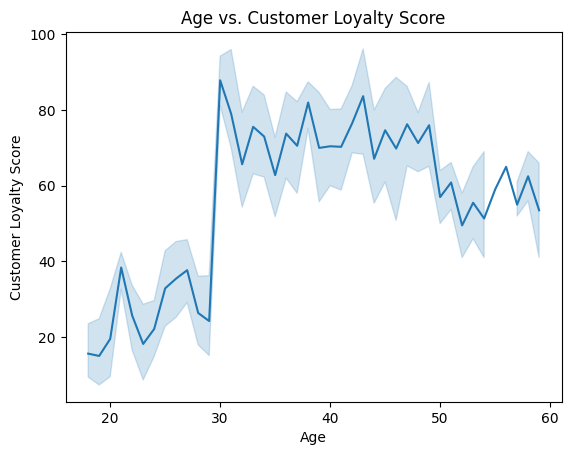

In [11]:
# prompt: Using dataframe data_sorted: plot a line graph of Age to customer loyalty score

import seaborn as sns
import matplotlib.pyplot as plt

# Create the line plot
sns.lineplot(x='Age', y='Customer Loyalty Score', data=data_sorted)

# Add labels and title
plt.xlabel('Age')
plt.ylabel('Customer Loyalty Score')
plt.title('Age vs. Customer Loyalty Score')

# Display the plot
plt.show()


In [13]:
# prompt: from data_sorted group Preferred Product Category by age

# Group the sorted data by 'Age' and 'Preferred Product Category' and count occurrences
grouped_data = data_sorted.groupby(['Age', 'Preferred Product Category']).size().reset_index(name='Count')

# Display the grouped data
grouped_data


,Age,Preferred Product Category,Count
0,18,Clothing,4
1,18,Furniture,3
2,18,Groceries,2
3,18,Sports,1
4,19,Clothing,2
...,...,...,...
138,57,Groceries,1
139,58,Clothing,1
140,58,Groceries,1
141,59,Clothing,1


In [14]:
# prompt: Using dataframe grouped_data: plot a bar graph of Preferred Product Category by age

import altair as alt

alt.Chart(grouped_data).mark_bar().encode(
    x='Age',
    y='Count',
    color='Preferred Product Category'
)


alt.Chart(...)

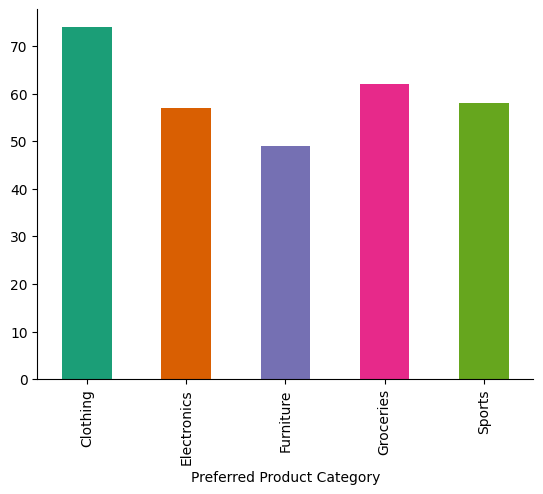

In [8]:
# @title Preferred Product Category

from matplotlib import pyplot as plt
import seaborn as sns
data.groupby('Preferred Product Category').size().plot(kind='bar', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

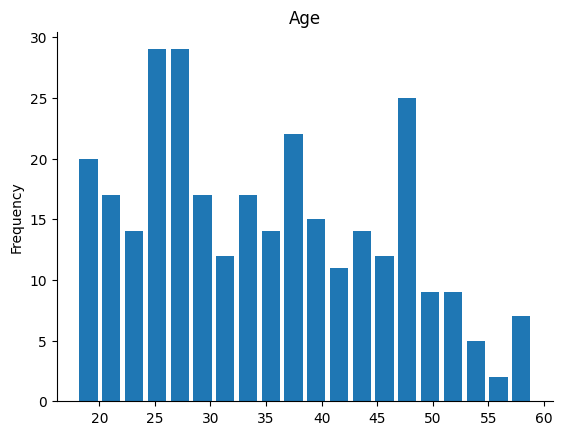

In [5]:
from matplotlib import pyplot as plt
data['Age'].plot(kind='hist', bins=20, title='Age', rwidth=0.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [6]:
# Convert categorical variables (Gender, Preferred Product Category) to numerical values
data_encoded = pd.get_dummies(data, columns=['Gender', 'Preferred Product Category'], drop_first=True)

# Standardize the numeric data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_encoded)



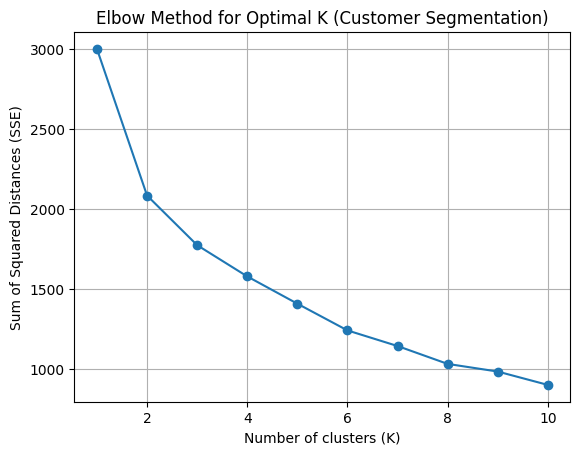

In [7]:
# K-Means Clustering with Elbow Method
sse = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    sse.append(kmeans.inertia_)

# Plot the elbow graph
plt.plot(k_values, sse, marker='o')
plt.title('Elbow Method for Optimal K (Customer Segmentation)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Sum of Squared Distances (SSE)')
plt.grid(True)
plt.show()




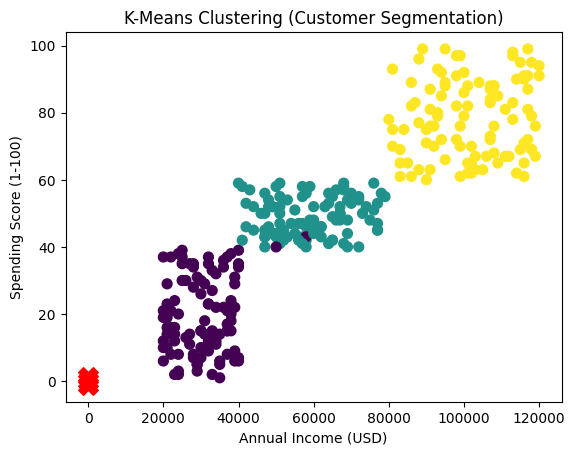

In [ ]:
# Apply K-Means with the optimal number of clusters (assuming K=3 from elbow method)
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(data_scaled)

# Visualize clusters based on income and spending score
plt.scatter(data['Annual Income (USD)'], data['Spending Score (1-100)'], c=data['Cluster'], s=50, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], s=200, c='red', marker='X')
plt.title('K-Means Clustering (Customer Segmentation)')
plt.xlabel('Annual Income (USD)')
plt.ylabel('Spending Score (1-100)')
plt.show()



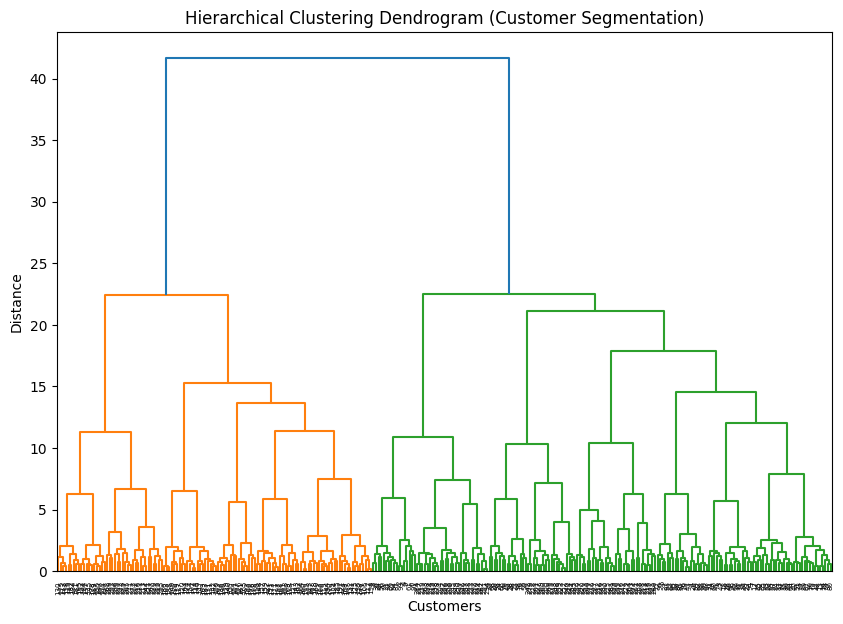

In [8]:
# Perform Hierarchical Clustering (Agglomerative)
Z = linkage(data_scaled, method='ward')

# Visualize the Dendrogram for Hierarchical Clustering
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram (Customer Segmentation)')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()